## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, norm

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

## **Data Description**




In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/datasets/student_performance.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.shape

(6607, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## **Data Preprocessing**

In [ ]:
data = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Motivation_Level', 'Exam_Score']]
data.head()

,Hours_Studied,Attendance,Sleep_Hours,Motivation_Level,Exam_Score
0,23,84,7,Low,67
1,19,64,8,Low,61
2,24,98,7,Medium,74
3,29,89,8,Medium,71
4,19,92,6,Medium,70


In [ ]:
data['Sleep_Category'] = pd.cut(
    data['Sleep_Hours'],
    bins=[0,4,7,10],
    labels=['Low','Medium','High']
)
data['Study_Level'] = pd.cut(
    data['Hours_Studied'],
    bins=[0,21,42,70],
    labels=['Low','Medium','High']
)
data['Attendance_Level'] = pd.cut(
    data['Attendance'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High']
)
final_data = data.drop(['Hours_Studied', 'Attendance', 'Sleep_Hours'], axis=1)

/tmp/ipykernel_407/2142257524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sleep_Category'] = pd.cut(
/tmp/ipykernel_407/2142257524.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Study_Level'] = pd.cut(
/tmp/ipykernel_407/2142257524.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

In [ ]:
final_data.head()

,Motivation_Level,Exam_Score,Sleep_Category,Study_Level,Attendance_Level
0,Low,67,Medium,Medium,High
1,Low,61,High,Low,Medium
2,Medium,74,Medium,Medium,High
3,Medium,71,High,Medium,High
4,Medium,70,Medium,Low,High


## **Factor-wise ANOVA Testing**

In [ ]:
factor = "Motivation_Level"
target = "Exam_Score"
groups = [group[target].values for name, group in final_data.groupby(factor)]
group_names = final_data[factor].unique()

In [ ]:
group_means = [np.mean(g) for g in groups]
overall_mean = np.mean(np.concatenate(groups))
n_i = [len(g) for g in groups]
k = len(groups)
N = sum(n_i)
# SSB
SSB = sum(n_i[i] * (group_means[i] - overall_mean)**2 for i in range(k))
# SSW
SSW = sum(sum((x - group_means[i])**2 for x in groups[i]) for i in range(k))
# Degrees of freedom
df_between = k - 1
df_within = N - k
# MS
MSB = SSB / df_between
MSW = SSW / df_within
# F
F_stat, p_value = f_oneway(*groups)
print("SSB:", SSB)
print("SSW:", SSW)
print("MSB:", MSB)
print("MSW:", MSW)
print("F-statistic:", F_stat)
print("p-value:", p_value)

SSB: 772.6976669110273
SSW: 99213.38103749353
MSB: 386.34883345551367
MSW: 15.023225475089873
F-statistic: 25.716769950376104
p-value: 7.492319380241663e-12


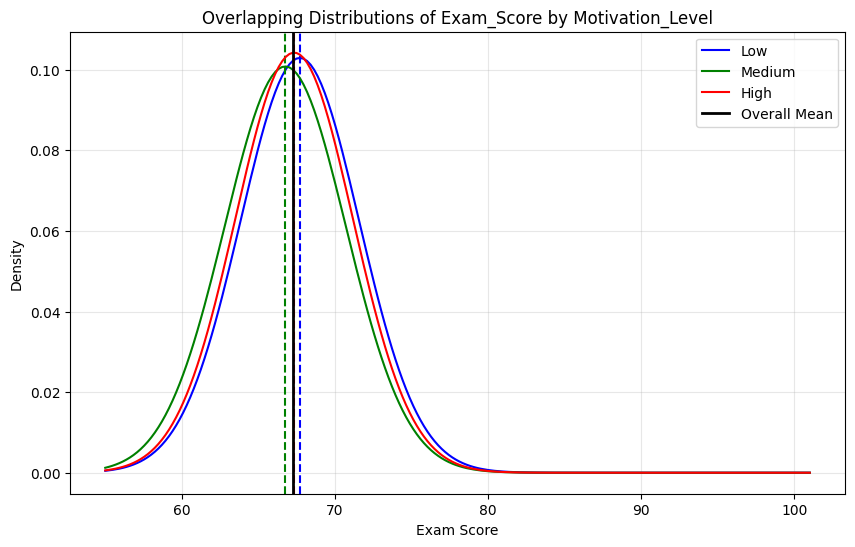

In [ ]:
plt.figure(figsize=(10,6))
for i, g in enumerate(groups):
    mean = np.mean(g)
    std = np.std(g)
    x = np.linspace(min(df[target]), max(df[target]), 200)
    y = norm.pdf(x, mean, std)
    # Curve
    plt.plot(x, y, color=colors[i], label=f"{group_names[i]}")
    # Mean line
    plt.axvline(mean, color=colors[i], linestyle='--')
# Overall mean
plt.axvline(overall_mean, color='black', linewidth=2, label='Overall Mean')
plt.title(f"Overlapping Distributions of {target} by {factor}")
plt.xlabel("Exam Score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Motivation level has a statistically significant effect on exam performance, as reflected by a relatively high F-statistic and an extremely low p-value, leading to the rejection of the null hypothesis. However, from a visual perspective, the distributions of exam scores across different motivation levels show substantial overlap, and the differences in mean values are relatively small. This suggests that while the effect is statistically detectable, its practical impact on performance is limited. Therefore, motivation level may influence exam scores, but it is not a strong differentiating factor compared to other variables.

In [ ]:
factor = "Sleep_Category"
target = "Exam_Score"
groups = [group[target].values for name, group in final_data.groupby(factor)]
group_names = final_data[factor].unique()

/tmp/ipykernel_407/3639549196.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[target].values for name, group in final_data.groupby(factor)]


In [ ]:
group_means = [np.mean(g) for g in groups]
overall_mean = np.mean(np.concatenate(groups))
n_i = [len(g) for g in groups]
k = len(groups)
N = sum(n_i)
# SSB
SSB = sum(n_i[i] * (group_means[i] - overall_mean)**2 for i in range(k))
# SSW
SSW = sum(sum((x - group_means[i])**2 for x in groups[i]) for i in range(k))
# Degrees of freedom
df_between = k - 1
df_within = N - k
# MS
MSB = SSB / df_between
MSW = SSW / df_within
# F
F_stat, p_value = f_oneway(*groups)
print("SSB:", SSB)
print("SSW:", SSW)
print("MSB:", MSB)
print("MSW:", MSW)
print("F-statistic:", F_stat)
print("p-value:", p_value)

SSB: 53.398675450842866
SSW: 99932.68002895288
MSB: 26.699337725421433
MSW: 15.132144159441683
F-statistic: 1.7644120650781725
p-value: 0.17136819857764443


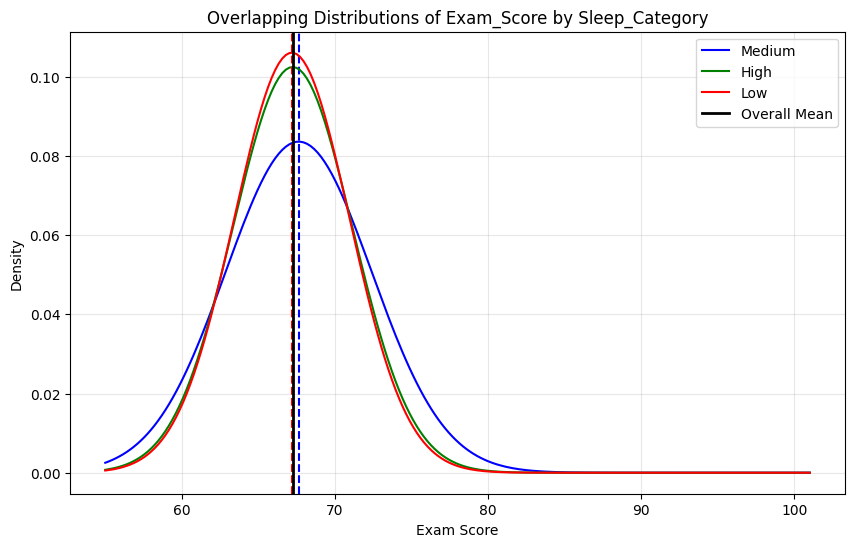

In [ ]:
plt.figure(figsize=(10,6))
for i, g in enumerate(groups):
    mean = np.mean(g)
    std = np.std(g)
    x = np.linspace(min(df[target]), max(df[target]), 200)
    y = norm.pdf(x, mean, std)
    # Curve
    plt.plot(x, y, color=colors[i], label=f"{group_names[i]}")
    # Mean line
    plt.axvline(mean, color=colors[i], linestyle='--')
# Overall mean
plt.axvline(overall_mean, color='black', linewidth=2, label='Overall Mean')
plt.title(f"Overlapping Distributions of {target} by {factor}")
plt.xlabel("Exam Score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Sleep category does not have a statistically significant impact on exam performance. The between-group variation SSB is very small compared to the within-group variation SSW, indicating that most of the variability in exam scores occurs within each sleep group rather than between them. This is further reflected in the mean square values, where MSB is only slightly higher than MSW, resulting in a relatively low F-statistic.
Additionally, the p-value is significantly greater than the standard significance level of 0.05, meaning there is insufficient evidence to reject the null hypothesis. From the graphical perspective, the distributions of exam scores for different sleep categories almost completely overlap, and their mean values are very close to each other. This indicates that variations in sleep duration, within the observed range, do not lead to meaningful differences in academic performance.

In [ ]:
factor = "Study_Level"
target = "Exam_Score"
groups = [group[target].values for name, group in final_data.groupby(factor)]
group_names = final_data[factor].unique()

/tmp/ipykernel_407/3266712127.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[target].values for name, group in final_data.groupby(factor)]


In [ ]:
group_means = [np.mean(g) for g in groups]
overall_mean = np.mean(np.concatenate(groups))
n_i = [len(g) for g in groups]
k = len(groups)
N = sum(n_i)
# SSB
SSB = sum(n_i[i] * (group_means[i] - overall_mean)**2 for i in range(k))
# SSW
SSW = sum(sum((x - group_means[i])**2 for x in groups[i]) for i in range(k))
# Degrees of freedom
df_between = k - 1
df_within = N - k
# MS
MSB = SSB / df_between
MSW = SSW / df_within
# F
F_stat, p_value = f_oneway(*groups)
print("SSB:", SSB)
print("SSW:", SSW)
print("MSB:", MSB)
print("MSW:", MSW)
print("F-statistic:", F_stat)
print("p-value:", p_value)

SSB: 12088.324979364399
SSW: 87897.75372504038
MSB: 6044.1624896821995
MSW: 13.309774943222347
F-statistic: 454.1145523095452
p-value: 1.637831337922884e-185


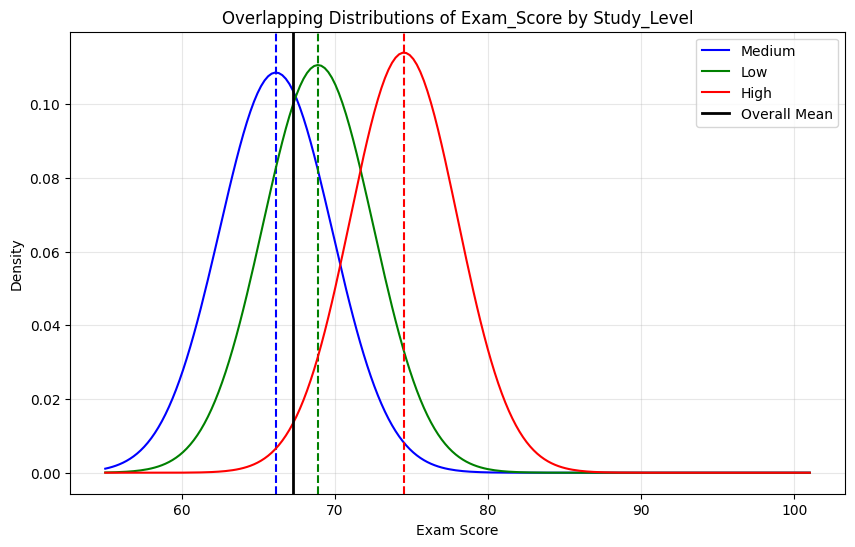

In [ ]:
plt.figure(figsize=(10,6))
for i, g in enumerate(groups):
    mean = np.mean(g)
    std = np.std(g)
    x = np.linspace(min(df[target]), max(df[target]), 200)
    y = norm.pdf(x, mean, std)
    # Curve
    plt.plot(x, y, color=colors[i], label=f"{group_names[i]}")
    # Mean line
    plt.axvline(mean, color=colors[i], linestyle='--')
# Overall mean
plt.axvline(overall_mean, color='black', linewidth=2, label='Overall Mean')
plt.title(f"Overlapping Distributions of {target} by {factor}")
plt.xlabel("Exam Score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Study level has a highly significant impact on exam performance. The between-group variation SSB is substantially large compared to the within-group variation SSW, indicating that differences in group means contribute significantly to the total variation in exam scores. This is further reinforced by the mean square values, where MSB is dramatically higher than MSW, resulting in an exceptionally high F-statistic.
Moreover, the p-value is extremely small, effectively zero, and far below any conventional significance threshold. This provides overwhelming evidence to reject the null hypothesis. From the graphical perspective, the distributions for different study levels are well separated with minimal overlap, and their mean values show a clear increasing trend from low to high study levels. This indicates that higher study engagement is strongly associated with improved exam performance.

In [ ]:
factor = "Attendance_Level"
target = "Exam_Score"
groups = [group[target].values for name, group in final_data.groupby(factor)]
group_names = final_data[factor].unique()

/tmp/ipykernel_407/3610974998.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[target].values for name, group in final_data.groupby(factor)]


In [ ]:
group_means = [np.mean(g) for g in groups]
overall_mean = np.mean(np.concatenate(groups))
n_i = [len(g) for g in groups]
k = len(groups)
N = sum(n_i)
# SSB
SSB = sum(n_i[i] * (group_means[i] - overall_mean)**2 for i in range(k))
# SSW
SSW = sum(sum((x - group_means[i])**2 for x in groups[i]) for i in range(k))
# Degrees of freedom
df_between = k - 1
df_within = N - k
# MS
MSB = SSB / df_between
MSW = SSW / df_within
# F
F_stat, p_value = f_oneway(*groups)
print("SSB:", SSB)
print("SSW:", SSW)
print("MSB:", MSB)
print("MSW:", MSW)
print("F-statistic:", F_stat)
print("p-value:", p_value)

SSB: 25575.447518519526
SSW: 74410.63118588494
MSB: 12787.723759259763
MSW: 11.26750926497349
F-statistic: 1134.9201903043634
p-value: 0.0


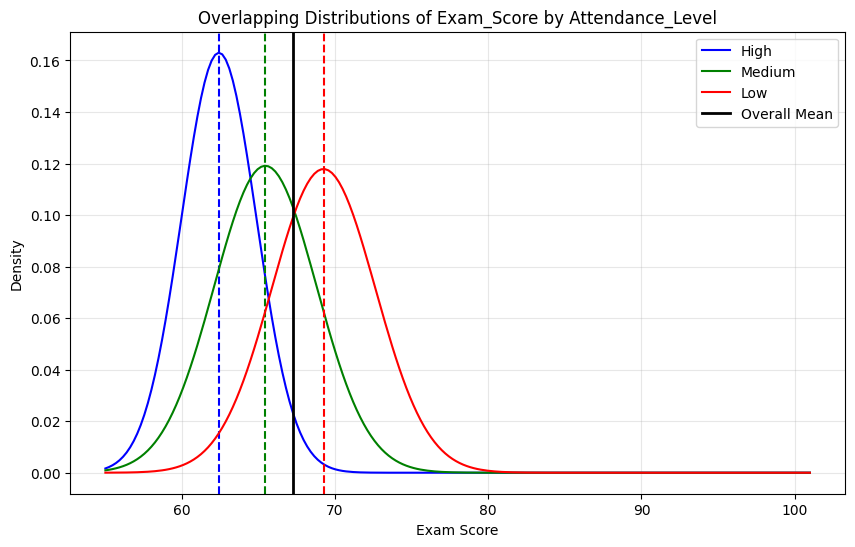

In [ ]:
plt.figure(figsize=(10,6))
for i, g in enumerate(groups):
    mean = np.mean(g)
    std = np.std(g)
    x = np.linspace(min(df[target]), max(df[target]), 200)
    y = norm.pdf(x, mean, std)
    # Curve
    plt.plot(x, y, color=colors[i], label=f"{group_names[i]}")
    # Mean line
    plt.axvline(mean, color=colors[i], linestyle='--')
# Overall mean
plt.axvline(overall_mean, color='black', linewidth=2, label='Overall Mean')
plt.title(f"Overlapping Distributions of {target} by {factor}")
plt.xlabel("Exam Score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Attendance level has a highly significant effect on exam performance.** The between-group variation **SSB is extremely large relative to the within-group variation SSW**, indicating that differences in attendance levels contribute substantially to the variation in exam scores. This is further supported by the **MSB which is vastly greater than MSW**, resulting in an **exceptionally high F-statistic.**
Additionally, the **p-value is effectively 0, which is far below the standard significance threshold of 0.05**, providing overwhelming evidence to reject the null hypothesis. From the graphical perspective, the distributions for different attendance levels are clearly separated with **minimal overlap, and there is a strong upward shift in mean scores as attendance increases**. This demonstrates a clear and consistent relationship between higher attendance and better academic performance.